In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

In [6]:
class CustomDataset:

    def __init__(self, root):

        self.samples = []

        classes = sorted(os.listdir(root))

        for label in classes:

            folder = os.path.join(root, label)

            for image_name in os.listdir(folder):

                image_path = os.path.join(folder, image_name)

                self.samples.append(
                    (image_path, int(label))
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("L")

        image = np.array(image, dtype=np.float32)

        # Normalization
        image = (image - 127.5) / 127.5

        image = torch.tensor(image).unsqueeze(0)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [7]:
class CustomDataLoader:

    def __init__(self, dataset, batch_size=32, shuffle=True):

        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.indices = list(range(len(dataset)))

    def __len__(self):

        return (len(self.dataset)+self.batch_size-1)//self.batch_size

    def __iter__(self):

        if self.shuffle:

            random.shuffle(self.indices)

        self.current = 0

        return self

    def __next__(self):

        if self.current >= len(self.indices):

            raise StopIteration

        batch_indices = self.indices[
            self.current:self.current+self.batch_size
        ]

        images = []
        labels = []

        for idx in batch_indices:

            image, label = self.dataset[idx]

            images.append(image)
            labels.append(label)

        self.current += self.batch_size

        images = torch.stack(images)

        labels = torch.tensor(labels)

        return images, labels

In [8]:
train_dataset = CustomDataset("MNIST/train")

test_dataset = CustomDataset("MNIST/test")

trainloader = CustomDataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

testloader = CustomDataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

images, labels = next(iter(trainloader))

print(images.shape)

cuda
torch.Size([64, 1, 28, 28])


In [9]:
class FlexibleCNN(nn.Module):

    def __init__(self, norm="batch"):

        super().__init__()

        self.norm = norm

        self.conv1 = nn.Conv2d(1,32,3,padding=1)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)

        self.conv3 = nn.Conv2d(64,128,3,padding=1)

        # -------------------------
        # Normalization Layers
        # -------------------------

        if norm=="batch":

            self.norm1 = nn.BatchNorm2d(32)
            self.norm2 = nn.BatchNorm2d(64)
            self.norm3 = nn.BatchNorm2d(128)

        elif norm=="instance":

            self.norm1 = nn.InstanceNorm2d(32)
            self.norm2 = nn.InstanceNorm2d(64)
            self.norm3 = nn.InstanceNorm2d(128)

        elif norm=="group":

            self.norm1 = nn.GroupNorm(8,32)
            self.norm2 = nn.GroupNorm(8,64)
            self.norm3 = nn.GroupNorm(8,128)

        elif norm=="layer":

            self.norm1 = nn.LayerNorm([32,28,28])
            self.norm2 = nn.LayerNorm([64,14,14])
            self.norm3 = nn.LayerNorm([128,7,7])

        else:

            raise ValueError("Invalid normalization")

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(128*3*3,256)

        self.fc2 = nn.Linear(256,10)

    def forward(self,x):

        # Block 1

        x = self.conv1(x)

        x = self.norm1(x)

        x = self.relu(x)

        x = self.pool(x)

        # Block 2

        x = self.conv2(x)

        x = self.norm2(x)

        x = self.relu(x)

        x = self.pool(x)

        # Block 3

        x = self.conv3(x)

        x = self.norm3(x)

        x = self.relu(x)

        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [10]:
model = FlexibleCNN(
    norm="batch"
).to(device)

images, labels = next(iter(trainloader))

images = images.to(device)

output = model(images)

print(images.shape)

print(output.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])


In [11]:
def train(model, trainloader, testloader, epochs):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_loss_history = []
    train_acc_history = []

    test_loss_history = []
    test_acc_history = []

    for epoch in range(epochs):

        # ------------------------
        # Training
        # ------------------------

        model.train()

        running_loss = 0

        correct = 0
        total = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, pred = torch.max(outputs,1)

            total += labels.size(0)

            correct += (pred==labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total

        train_loss_history.append(train_loss)
        train_acc_history.append(train_acc)

        # ------------------------
        # Testing
        # ------------------------

        model.eval()

        running_loss = 0

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in testloader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, pred = torch.max(outputs,1)

                total += labels.size(0)

                correct += (pred==labels).sum().item()

        test_loss = running_loss / len(testloader)
        test_acc = 100 * correct / total

        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )

    return (
        train_loss_history,
        train_acc_history,
        test_loss_history,
        test_acc_history
    )

In [12]:
results = {}

normalizations = [
    "batch",
    "layer",
    "instance",
    "group"
]

for norm in normalizations:

    print("\n")
    print("="*60)
    print(f"Training using {norm.upper()} Normalization")
    print("="*60)

    model = FlexibleCNN(norm=norm).to(device)

    train_loss, train_acc, test_loss, test_acc = train(
        model,
        trainloader,
        testloader,
        epochs=5
    )

    results[norm] = {

        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc

    }



Training using BATCH Normalization
Epoch 1/5 | Train Loss: 0.1029 | Train Acc: 96.88% | Test Loss: 0.0430 | Test Acc: 98.67%
Epoch 2/5 | Train Loss: 0.0367 | Train Acc: 98.80% | Test Loss: 0.0470 | Test Acc: 98.61%
Epoch 3/5 | Train Loss: 0.0258 | Train Acc: 99.17% | Test Loss: 0.0319 | Test Acc: 99.00%
Epoch 4/5 | Train Loss: 0.0215 | Train Acc: 99.30% | Test Loss: 0.0242 | Test Acc: 99.17%
Epoch 5/5 | Train Loss: 0.0172 | Train Acc: 99.47% | Test Loss: 0.0348 | Test Acc: 98.97%


Training using LAYER Normalization
Epoch 1/5 | Train Loss: 0.1416 | Train Acc: 95.58% | Test Loss: 0.0349 | Test Acc: 98.86%
Epoch 2/5 | Train Loss: 0.0402 | Train Acc: 98.75% | Test Loss: 0.0359 | Test Acc: 98.89%
Epoch 3/5 | Train Loss: 0.0271 | Train Acc: 99.11% | Test Loss: 0.0379 | Test Acc: 98.71%
Epoch 4/5 | Train Loss: 0.0216 | Train Acc: 99.30% | Test Loss: 0.0259 | Test Acc: 99.16%
Epoch 5/5 | Train Loss: 0.0180 | Train Acc: 99.42% | Test Loss: 0.0258 | Test Acc: 99.12%


Training using INSTANCE 

In [13]:
print("\nFinal Comparison\n")

print("{:<15} {:>12} {:>12}".format(
    "Normalization",
    "Train Acc",
    "Test Acc"
))

print("-"*42)

for norm in normalizations:

    print("{:<15} {:>11.2f}% {:>11.2f}%".format(

        norm,

        results[norm]["train_acc"][-1],

        results[norm]["test_acc"][-1]

    ))


Final Comparison

Normalization      Train Acc     Test Acc
------------------------------------------
batch                 99.47%       98.97%
layer                 99.42%       99.12%
instance              99.34%       99.10%
group                 99.33%       99.19%


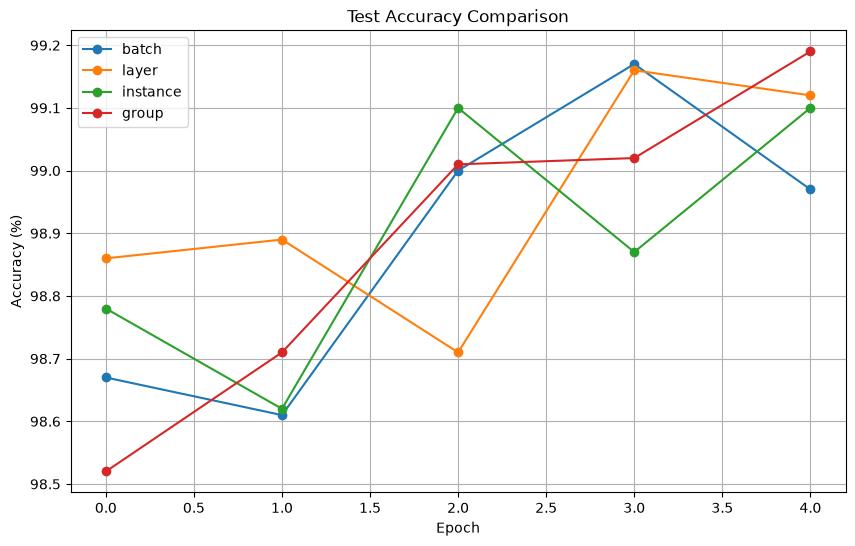

In [14]:
plt.figure(figsize=(10,6))

for norm in normalizations:

    plt.plot(
        results[norm]["test_acc"],
        marker="o",
        label=norm
    )

plt.title("Test Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

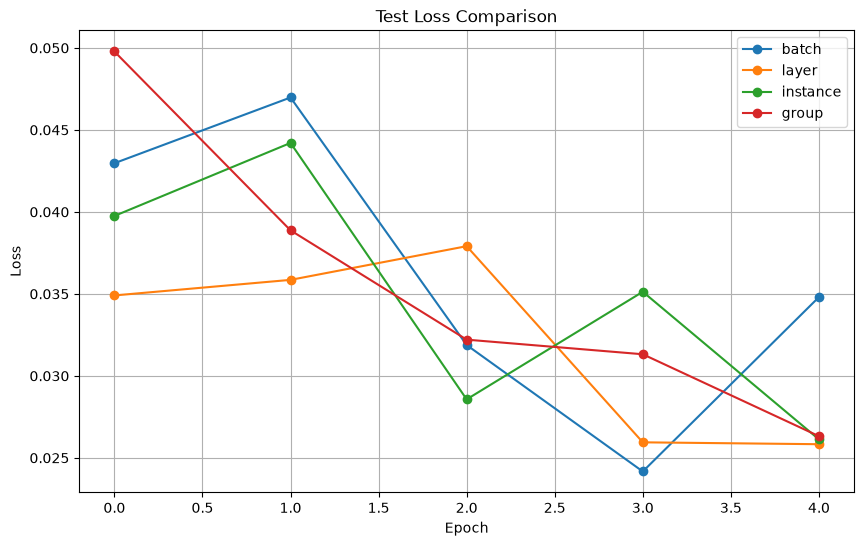

In [15]:
plt.figure(figsize=(10,6))

for norm in normalizations:

    plt.plot(
        results[norm]["test_loss"],
        marker="o",
        label=norm
    )

plt.title("Test Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

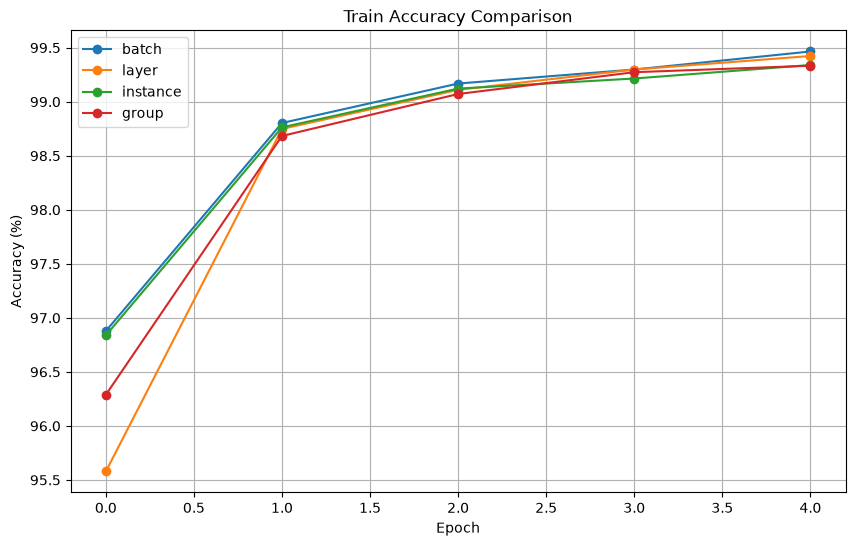

In [16]:
plt.figure(figsize=(10,6))

for norm in normalizations:

    plt.plot(
        results[norm]["train_acc"],
        marker="o",
        label=norm
    )

plt.title("Train Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

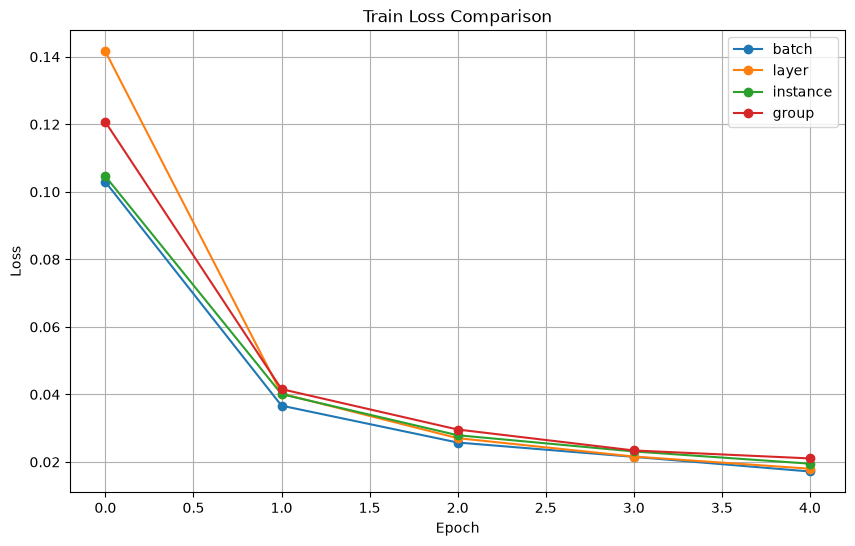

In [17]:
plt.figure(figsize=(10,6))

for norm in normalizations:

    plt.plot(
        results[norm]["train_loss"],
        marker="o",
        label=norm
    )

plt.title("Train Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()